In [1]:
import sys; sys.path.append("../src") 
import numpy as np
import pandas as pd
from xgboost import XGBClassifier

from data_prep import load_merged, temporal_split, numeric_features
from eval_harness import evaluate, pick_threshold_for_budget

df = load_merged("../data/raw")
train, val, test = temporal_split(df)

feats = numeric_features(train)
X_train, y_train = train[feats], train["isFraud"]
X_val,   y_val   = val[feats],   val["isFraud"]


In [2]:
def make_model(**kw):
    """One factory so every contender differs ONLY in what we explicitly pass."""
    return XGBClassifier(tree_method="hist", eval_metric="logloss",
                         n_jobs=-1, random_state=42, **kw)

m_base = make_model().fit(X_train, y_train)
proba_base = m_base.predict_proba(X_val)[:, 1]

results = [evaluate(y_val, proba_base, name="control (no handling)")]
pd.DataFrame(results).set_index("name")


,pr_auc,roc_auc,threshold,recall,precision,flagged,missed_fraud
name,,,,,,,
control (no handling),0.5571,0.905,0.5,0.3847,0.7798,2275,2837


In [3]:
spw = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {spw:.1f}")          # ≈ 27 — the imbalance ratio itself

m_w = make_model(scale_pos_weight=spw).fit(X_train, y_train)
proba_w = m_w.predict_proba(X_val)[:, 1]

results.append(evaluate(y_val, proba_w, name=f"scale_pos_weight={spw:.0f}"))
pd.DataFrame(results).set_index("name")


scale_pos_weight = 28.6


,pr_auc,roc_auc,threshold,recall,precision,flagged,missed_fraud
name,,,,,,,
control (no handling),0.5571,0.9050,0.5,0.3847,0.7798,2275,2837
scale_pos_weight=29,0.5252,0.8893,0.5,0.6940,0.2540,12598,1411


mean predicted P(fraud):  control=0.0374   weighted=0.2082   true rate=0.0390
rank correlation control vs weighted: 0.7594   (1.0 = identical ordering)


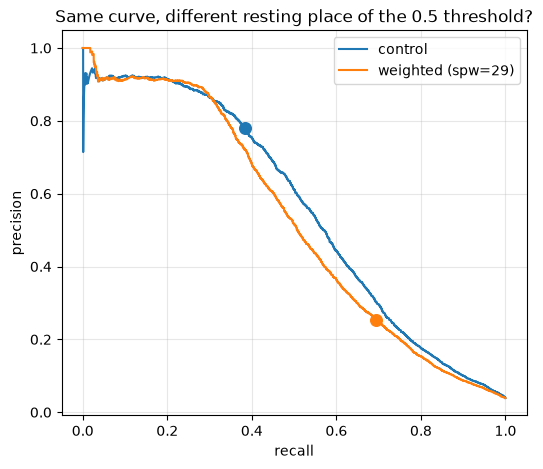

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# (a) Did the scores inflate? (they should — that's the odds × 27 effect)
print(f"mean predicted P(fraud):  control={proba_base.mean():.4f}   "
      f"weighted={proba_w.mean():.4f}   true rate={y_val.mean():.4f}")

# (b) Did the RANKING change? Spearman correlation of the two score orderings
from scipy.stats import spearmanr
rho = spearmanr(proba_base, proba_w).statistic
print(f"rank correlation control vs weighted: {rho:.4f}   (1.0 = identical ordering)")

# (c) The picture: both PR curves on one axes
plt.figure(figsize=(6, 5))
for proba, label in [(proba_base, "control"), (proba_w, f"weighted (spw={spw:.0f})")]:
    p, r, _ = precision_recall_curve(y_val, proba)
    plt.plot(r, p, label=label)
# mark where threshold 0.5 lands on EACH curve
from sklearn.metrics import precision_score, recall_score
for proba, c in [(proba_base, "tab:blue"), (proba_w, "tab:orange")]:
    plt.scatter(recall_score(y_val, proba >= .5),
                precision_score(y_val, proba >= .5), color=c, zorder=5, s=70)
plt.xlabel("recall"); plt.ylabel("precision")
plt.title("Same curve, different resting place of the 0.5 threshold?")
plt.legend(); plt.grid(alpha=.3); plt.show()


In [6]:
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# ============ DELIBERATELY WRONG — the classic leakage bug ============
X_all, y_all = df[feats], df["isFraud"]

imp_bad = SimpleImputer(strategy="median")
X_all_imp = imp_bad.fit_transform(X_all)               # (also leaky, quietly)

Xs, ys = SMOTE(random_state=42).fit_resample(X_all_imp, y_all)   # oversample EVERYTHING
print(f"after SMOTE: {len(ys):,} rows, fraud rate {ys.mean():.2f}")  # ~50/50!

# then split the contaminated data
X_tr, X_te, y_tr, y_te = train_test_split(Xs, ys, test_size=0.2,
                                          stratify=ys, random_state=42)
m_bad = make_model().fit(X_tr, y_tr)
proba_bad = m_bad.predict_proba(X_te)[:, 1]
print(evaluate(y_te, proba_bad, name="SMOTE before split (WRONG)"))


after SMOTE: 1,139,754 rows, fraud rate 0.50
{'name': 'SMOTE before split (WRONG)', 'pr_auc': 0.9979, 'roc_auc': 0.9972, 'threshold': 0.5, 'recall': np.float64(0.9776), 'precision': np.float64(0.9976), 'flagged': 111687, 'missed_fraud': 2558}


In [7]:
# fit the imputer on TRAIN ONLY (even preprocessing must not see val)
imp = SimpleImputer(strategy="median").fit(X_train)
X_train_imp = imp.transform(X_train)
X_val_imp   = imp.transform(X_val)

smote = SMOTE(random_state=42)          # default: oversample fraud to 50/50
X_sm, y_sm = smote.fit_resample(X_train_imp, y_train)
print(f"train: {len(y_train):,} rows -> {len(y_sm):,} rows, "
      f"fraud rate {y_train.mean():.3f} -> {y_sm.mean():.2f}")

m_smote = make_model().fit(X_sm, y_sm)
proba_smote = m_smote.predict_proba(X_val_imp)[:, 1]   # eval on REAL, untouched val

results.append(evaluate(y_val, proba_smote, name="SMOTE (correct)"))
pd.DataFrame(results).set_index("name")


train: 354,324 rows -> 684,672 rows, fraud rate 0.034 -> 0.50


,pr_auc,roc_auc,threshold,recall,precision,flagged,missed_fraud
name,,,,,,,
control (no handling),0.5571,0.9050,0.5,0.3847,0.7798,2275,2837
scale_pos_weight=29,0.5252,0.8893,0.5,0.6940,0.2540,12598,1411
SMOTE (correct),0.5601,0.8951,0.5,0.3839,0.7951,2226,2841


In [8]:
print(f"mean P(fraud): control={proba_base.mean():.4f}  smote={proba_smote.mean():.4f}  weighted={proba_w.mean():.4f}")


mean P(fraud): control=0.0374  smote=0.0430  weighted=0.2082


In [9]:
BUDGET = 3000
rows = []
for name, proba in [("control", proba_base),
                    ("weighted", proba_w),
                    ("SMOTE", proba_smote)]:
    thr = pick_threshold_for_budget(proba, BUDGET)
    rows.append(evaluate(y_val, proba, threshold=thr, name=f"{name} @ budget"))
pd.DataFrame(rows).set_index("name")


,pr_auc,roc_auc,threshold,recall,precision,flagged,missed_fraud
name,,,,,,,
control @ budget,0.5571,0.9050,0.314342,0.4487,0.6897,3000,2542
weighted @ budget,0.5252,0.8893,0.852767,0.4196,0.6448,3001,2676
SMOTE @ budget,0.5601,0.8951,0.343549,0.4461,0.6857,3000,2554


In [ ]:
## Findings

Three imbalance treatments, identical model + temporal harness, judged on real val data:

| | PR-AUC | vs control |
|---|---|---|
| Control (no handling) | 0.557 | — |
| scale_pos_weight=29 | 0.525 | −0.032 |
| SMOTE (correct) | 0.560 | +0.003 (noise) |
| SMOTE before split (WRONG) | **0.998** | fake |

1. **No rebalancing technique added knowledge.** PR-AUC is a ranking metric; reweighting
   and resampling re-shout the same information. Weighting slightly *hurt* the ranking;
   SMOTE was a wash. Both mainly relocate the default threshold along the same PR curve —
   recall@0.5 jumped to 69% under weighting, but the control reaches any such point by
   explicit threshold choice, transparently.
2. **Class weighting destroys calibration by design** (mean predicted fraud rate 0.21 vs
   true 0.039). Raw weighted scores are not probabilities.
3. **The SMOTE leakage bug reproduced:** resampling before the split scores 0.998 —
   synthetic near-copies of test rows leak into training AND the test set becomes 50%
   synthetic fraud. This is the inflated number many public fraud projects report.
4. **SMOTE isn't free:** its kNN step cannot handle missing values, forcing median
   imputation into a pipeline XGBoost didn't need it in.
5. **At a fixed review budget (3,000 flags) all three catch ~the same fraud**
   (44.9% / 42.0% / 44.6% recall) — confirming the 0.5-threshold differences were
   threshold placement, not model skill.
6. **SMOTE's synthetic manifold didn't transfer:** mean predicted fraud rate on real
   val data 0.043 (vs base rate 0.039) — the model scored real transactions almost
   exactly like the control despite training on 50/50 data.


**Decision: carry the control model + explicit validation-tuned thresholds forward.
Next lever: feature engineering (04) — the only thing left that can lift the curve.**
